In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

print("Environment ready!")

Environment ready!


# Tsunami Evacuation Accessibility & Network Resilience

## Data Exploration

Exploration of tsunami hazard and evacuation datasets for the Long Beach Peninsula, Washington.

In [2]:
layer_url = (
    "https://gis.dnr.wa.gov/site3/rest/services/"
    "Geology/Tsunami_Hazard/FeatureServer/29"
)

response = requests.get(
    layer_url,
    params={"f": "json"}
)

response.raise_for_status()
metadata = response.json()

print("Layer name:", metadata["name"])
print("Geometry type:", metadata["geometryType"])
print("Maximum records per request:", metadata["maxRecordCount"])

Layer name: M9.0 Cascadia L1 Tsunami Inundation Extent
Geometry type: esriGeometryPolygon
Maximum records per request: 2000


In [3]:
fields = pd.DataFrame(
    [
        {
            "name": field["name"],
            "type": field["type"],
            "alias": field.get("alias")
        }
        for field in metadata["fields"]
    ]
)

fields

,name,type,alias
0,OBJECTID,esriFieldTypeOID,OBJECTID
1,TSUNAMI_SCENARIO_DESCRIPTION,esriFieldTypeString,Tsunami Scenario Description
2,TSUNAMI_SCENARIO_NAME,esriFieldTypeString,Tsunami Scenario Name
3,CITATION,esriFieldTypeString,Citation
4,HYPERLINK,esriFieldTypeString,Hyperlink
5,Shape__Length,esriFieldTypeDouble,Shape_Length
6,Shape__Area,esriFieldTypeDouble,Shape_Area
7,STUDY_TYPE,esriFieldTypeString,Study Type
8,GLOBALID,esriFieldTypeGlobalID,GLOBALID


In [4]:
query_url = f"{layer_url}/query"

response = requests.get(
    query_url,
    params={
        "where": "1=1",
        "returnCountOnly": "true",
        "f": "json"
    }
)

response.raise_for_status()

feature_count = response.json()["count"]

print("Number of features:", feature_count)

Number of features: 8


In [5]:
query_url = f"{layer_url}/query"

params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "outSR": 4326,
    "f": "geojson"
}

response = requests.get(query_url, params=params)
response.raise_for_status()

tsunami_geojson = response.json()

print("Features downloaded:", len(tsunami_geojson["features"]))

Features downloaded: 8


In [6]:
tsunami = gpd.GeoDataFrame.from_features(
    tsunami_geojson["features"],
    crs="EPSG:4326"
)

tsunami.head()

,geometry,OBJECTID,TSUNAMI_SCENARIO_DESCRIPTION,TSUNAMI_SCENARIO_NAME,CITATION,HYPERLINK,Shape__Length,Shape__Area,STUDY_TYPE,GLOBALID
0,"MULTIPOLYGON (((-124.0953 46.25277, -124.07433...",2,Scenario L1; Modeled after a simulated 9.0 mag...,Cascadia subduction zone M9.0,"Eungard, D. W.; Forson, Corina; Walsh, T. J.; ...",https://www.dnr.wa.gov/publications/ger_ms2018...,4.876760e+06,2.468984e+10,Regional Tsunami Inundation Study,{C67B6495-3E1C-4675-A2B2-75E0B3F2CDEF}
1,"POLYGON ((-122.73974 48.15027, -122.81038 48.1...",3,Scenario L1; Modeled after a simulated 9.0 mag...,Cascadia subduction zone M9.0,"Eungard, D. W.; Forson, Corina; Walsh, T. J.; ...",https://www.dnr.wa.gov/Publications/ger_ms2018...,1.194613e+05,2.697842e+08,Regional Tsunami Inundation Study,{B5CC62C9-DEB8-445A-BEED-F38B3479618B}
2,"POLYGON ((-124.55289 48.43495, -124.79991 48.4...",4,Scenario L1-extended; Modeled after a simulate...,Cascadia subduction zone M9.0,"Dolcimascolo, Alexander; Eungard, D. W.; Allen...",https://fortress.wa.gov/dnr/geologydata/tsunam...,5.037398e+06,3.193335e+10,Regional Tsunami Inundation Study,{E91FD321-6967-467F-9D3C-A5EF165787DE}
3,"MULTIPOLYGON (((-122.75459 48.99693, -122.7545...",5,Scenario L1-extended; Modeled after a simulate...,Cascadia subduction zone M9.0,"Dolcimascolo, Alexander; Eungard, D. W.; Allen...",https://fortress.wa.gov/dnr/geologydata/tsunam...,1.248694e+07,3.982433e+10,Regional Tsunami Inundation Study,{97B1B0C7-F203-4A1A-BE6A-AE7E4777886B}
4,"MULTIPOLYGON (((-123.08362 46.17748, -123.0836...",6,Scenario L1; Modeled after a simulated 9.0 mag...,Cascadia subduction zone M9.0,"Allan, J. C.; Zhang, Joseph; O'Brien, F. E.; G...",https://www.oregongeology.org/pubs/sp/SP-51/SP...,2.280569e+06,2.230673e+09,Regional Tsunami Inundation Study,{B365B7F0-403F-4C72-B882-D752F1708404}


In [7]:
tsunami.shape

(8, 10)

In [8]:
tsunami.columns

Index(['geometry', 'OBJECTID', 'TSUNAMI_SCENARIO_DESCRIPTION',
       'TSUNAMI_SCENARIO_NAME', 'CITATION', 'HYPERLINK', 'Shape__Length',
       'Shape__Area', 'STUDY_TYPE', 'GLOBALID'],
      dtype='str')

In [9]:
tsunami.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
tsunami[
    [
        "TSUNAMI_SCENARIO_NAME",
        "TSUNAMI_SCENARIO_DESCRIPTION",
        "STUDY_TYPE"
    ]
]

,TSUNAMI_SCENARIO_NAME,TSUNAMI_SCENARIO_DESCRIPTION,STUDY_TYPE
0,Cascadia subduction zone M9.0,Scenario L1; Modeled after a simulated 9.0 mag...,Regional Tsunami Inundation Study
1,Cascadia subduction zone M9.0,Scenario L1; Modeled after a simulated 9.0 mag...,Regional Tsunami Inundation Study
2,Cascadia subduction zone M9.0,Scenario L1-extended; Modeled after a simulate...,Regional Tsunami Inundation Study
3,Cascadia subduction zone M9.0,Scenario L1-extended; Modeled after a simulate...,Regional Tsunami Inundation Study
4,Cascadia subduction zone M9.0,Scenario L1; Modeled after a simulated 9.0 mag...,Regional Tsunami Inundation Study
5,Cascadia subduction zone M9.0,Scenario L1; Modeled after a simulated 9.0 mag...,Regional Tsunami Inundation Study
6,Cascadia subduction zone M9.0,Scenario L1; Modeled after a simulated 9.0 mag...,Regional Tsunami Inundation Study
7,Cascadia subduction zone M9.0,Scenario L1; Modeled after a simulated 9.0 mag...,Regional Tsunami Inundation Study


In [11]:
tsunami["TSUNAMI_SCENARIO_NAME"].value_counts(dropna=False)

TSUNAMI_SCENARIO_NAME
Cascadia subduction zone M9.0    8
Name: count, dtype: int64

In [12]:
tsunami["TSUNAMI_SCENARIO_NAME"].unique()

<StringArray>
['Cascadia subduction zone M9.0']
Length: 1, dtype: str

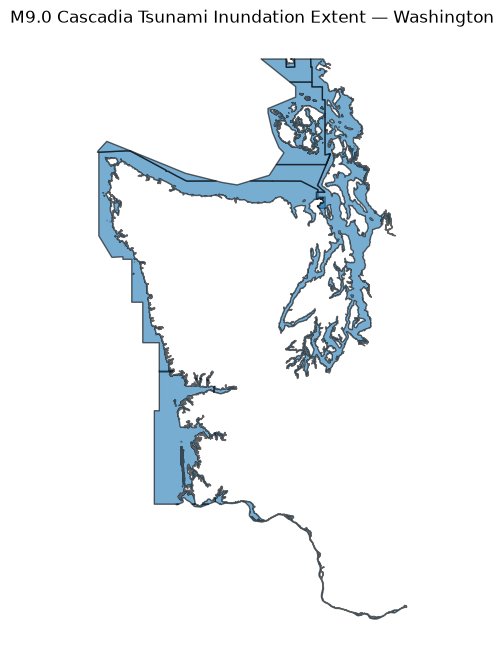

In [13]:
ax = tsunami.plot(
    figsize=(10, 8),
    edgecolor="black",
    alpha=0.6
)

ax.set_title("M9.0 Cascadia Tsunami Inundation Extent — Washington")
ax.set_axis_off()

In [14]:
tsunami.total_bounds

array([-124.81256497,   45.54373331, -121.99729551,   49.00216583])

In [15]:
pd.set_option("display.max_colwidth", 120)

tsunami.drop(columns="geometry").T

,0,1,2,3,4,5,6,7
OBJECTID,2,3,4,5,6,7,21,23
TSUNAMI_SCENARIO_DESCRIPTION,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...,Scenario L1-extended; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a ...,Scenario L1-extended; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a ...,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...
TSUNAMI_SCENARIO_NAME,Cascadia subduction zone M9.0,Cascadia subduction zone M9.0,Cascadia subduction zone M9.0,Cascadia subduction zone M9.0,Cascadia subduction zone M9.0,Cascadia subduction zone M9.0,Cascadia subduction zone M9.0,Cascadia subduction zone M9.0
CITATION,"Eungard, D. W.; Forson, Corina; Walsh, T. J.; Gica, Edison; Arcas, Diego, 2018, Tsunami hazard maps of southwest Was...","Eungard, D. W.; Forson, Corina; Walsh, T. J.; Gonzalez, F. I.; LeVeque, R. J; Adams, L. M., 2018, Tsunami hazard map...","Dolcimascolo, Alexander; Eungard, D. W.; Allen, Corina; LeVeque, R. J.; Adams, L. M.; Arcas, Diego; Titov, V. V.; Go...","Dolcimascolo, Alexander; Eungard, D. W.; Allen, Corina; LeVeque, R. J.; Adams, L. M.; Arcas, Diego; Titov, V. V.; Go...","Allan, J. C.; Zhang, Joseph; O'Brien, F. E.; Gabel, L. L., 2018, Columbia River tsunami modeling: Toward improved ma...","Dolcimascolo, Alexander; Eungard D. W.; Allen, Corina, 2023, Tsunami hazard maps of the Chehalis, Hoquiam, Willapa, ...","Areas not modeled for tsunami inundation, but tsunami inundation and wave effects are anticipated","Walsh, T. J.; Gica, Edison; Arcas, Diego; Titov, V. V.; Eungard, D. W., 2016, Tsunami hazard maps of the San Juan Is..."
HYPERLINK,https://www.dnr.wa.gov/publications/ger_ms2018-01_tsunami_hazard_southwest_washington.zip,https://www.dnr.wa.gov/Publications/ger_ms2018-03_tsunami_hazard_pt_angeles_pt_townsend.zip,https://fortress.wa.gov/dnr/geologydata/tsunami_hazard_maps/ger_ms2022-01_tsunami_hazard_olympic_peninsula.zip,https://fortress.wa.gov/dnr/geologydata/tsunami_hazard_maps/ger_ms2021-01_tsunami_hazard_puget_sound.zip,https://www.oregongeology.org/pubs/sp/SP-51/SP-51_report.pdf,https://fortress.wa.gov/dnr/geologydata/tsunami_hazard_maps/ger_ms2023-02_tsunami_hazard_sw_wa_rivers.pdf,NaN,https://file.dnr.wa.gov/publications/ger_ms2016-01_tsunami_hazard_san_juan_islands.zip
Shape__Length,4876759.830063,119461.317273,5037398.123033,12486942.874305,2280568.90405,820902.290012,1388069.072787,2882088.59201
Shape__Area,24689835420.5751,269784163.632599,31933350377.0075,39824333942.537697,2230673283.07652,627242831.118967,11228211009.174999,13530303444.919001
STUDY_TYPE,Regional Tsunami Inundation Study,Regional Tsunami Inundation Study,Regional Tsunami Inundation Study,Regional Tsunami Inundation Study,Regional Tsunami Inundation Study,Regional Tsunami Inundation Study,Regional Tsunami Inundation Study,Regional Tsunami Inundation Study
GLOBALID,{C67B6495-3E1C-4675-A2B2-75E0B3F2CDEF},{B5CC62C9-DEB8-445A-BEED-F38B3479618B},{E91FD321-6967-467F-9D3C-A5EF165787DE},{97B1B0C7-F203-4A1A-BE6A-AE7E4777886B},{B365B7F0-403F-4C72-B882-D752F1708404},{75997C43-AC26-463D-9BCF-A099F011BCA3},{9B621AFB-4731-43A7-B5E1-ADFB1FFA486F},{13258B4D-6178-44B0-A419-FC0DE60BF970}


In [16]:
tsunami[
    ["TSUNAMI_SCENARIO_NAME", "STUDY_TYPE"]
]

,TSUNAMI_SCENARIO_NAME,STUDY_TYPE
0,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study
1,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study
2,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study
3,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study
4,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study
5,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study
6,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study
7,Cascadia subduction zone M9.0,Regional Tsunami Inundation Study


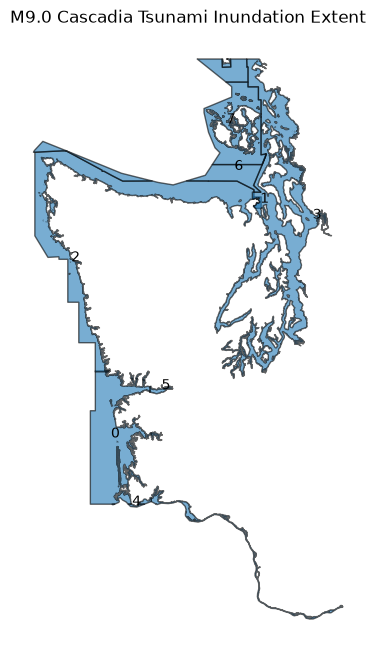

In [17]:
ax = tsunami.plot(
    figsize=(10, 8),
    edgecolor="black",
    alpha=0.6
)

for idx, geom in tsunami.geometry.items():
    point = geom.representative_point()
    ax.text(
        point.x,
        point.y,
        str(idx),
        fontsize=10
    )

ax.set_title("M9.0 Cascadia Tsunami Inundation Extent")
ax.set_axis_off()

In [18]:
feature_bounds = tsunami.geometry.bounds.copy()
feature_bounds["feature_id"] = tsunami.index

feature_bounds

,minx,miny,maxx,maxy,feature_id
0,-124.294769,46.252569,-123.739869,47.075867,0
1,-122.810378,48.079690,-122.739745,48.150266,1
2,-124.799999,47.069908,-122.804994,48.436099,2
3,-123.160556,47.029452,-122.100139,49.002166,3
4,-124.096783,45.543733,-121.997296,46.364126,4
5,-123.934585,46.646433,-123.544243,47.073208,5
6,-124.812565,48.180048,-122.692159,49.002166,6
7,-123.260112,48.350042,-122.700205,48.859217,7


Text(185.64236289412827, 0.5, 'Latitude')

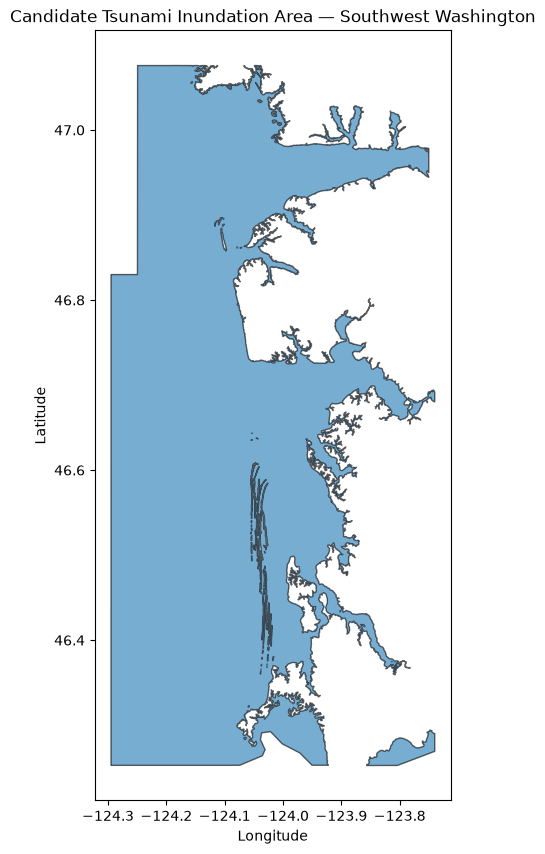

In [19]:
long_beach_candidate = tsunami.loc[[0]]

ax = long_beach_candidate.plot(
    figsize=(8, 10),
    edgecolor="black",
    alpha=0.6
)

ax.set_title("Candidate Tsunami Inundation Area — Southwest Washington")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

Text(66.22222222222221, 0.5, 'Latitude')

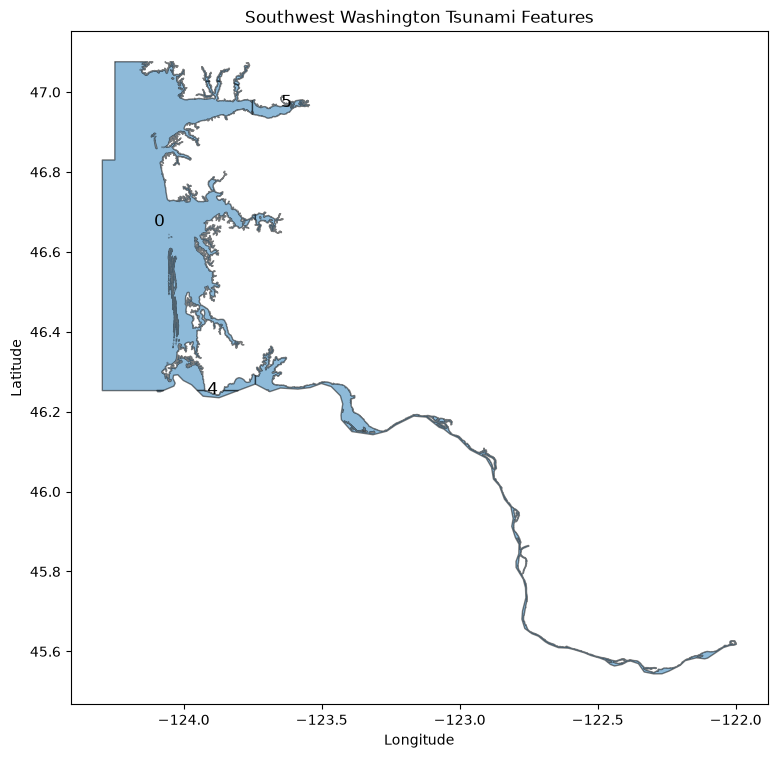

In [20]:
nearby_features = tsunami.loc[[0, 4, 5]]

ax = nearby_features.plot(
    figsize=(9, 10),
    edgecolor="black",
    alpha=0.5
)

for idx, geom in nearby_features.geometry.items():
    point = geom.representative_point()
    ax.text(point.x, point.y, str(idx), fontsize=12)

ax.set_title("Southwest Washington Tsunami Features")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [21]:
from shapely.geometry import box

study_bbox = box(
    -124.20, 46.25,   # west, south
    -123.85, 46.75    # east, north
)

study_area = gpd.GeoDataFrame(
    geometry=[study_bbox],
    crs="EPSG:4326"
)

Text(199.24070631385294, 0.5, 'Latitude')

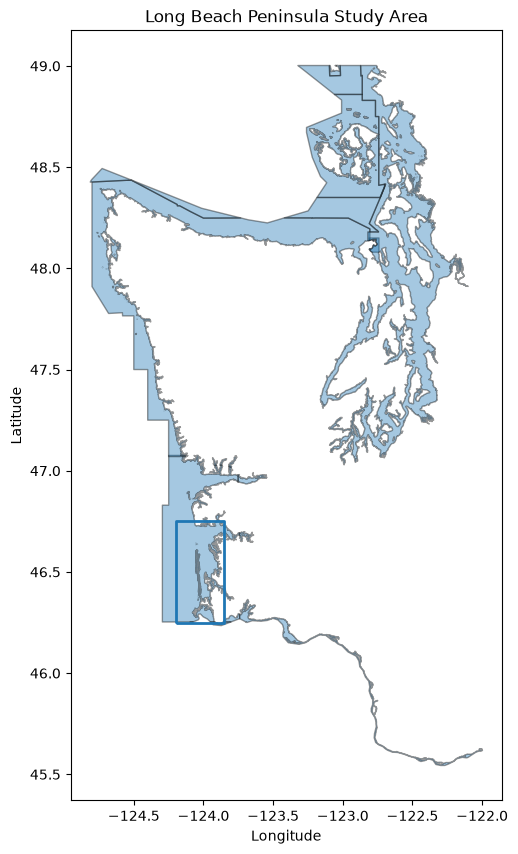

In [22]:
ax = tsunami.plot(
    figsize=(9, 10),
    edgecolor="black",
    alpha=0.4
)

study_area.boundary.plot(
    ax=ax,
    linewidth=2
)

ax.set_title("Long Beach Peninsula Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [23]:
relevant_tsunami = tsunami[
    tsunami.intersects(study_bbox)
].copy()

print("Relevant tsunami features:", len(relevant_tsunami))

Relevant tsunami features: 2


In [24]:
long_beach_hazard = gpd.clip(
    relevant_tsunami,
    study_area
)

long_beach_hazard

,geometry,OBJECTID,TSUNAMI_SCENARIO_DESCRIPTION,TSUNAMI_SCENARIO_NAME,CITATION,HYPERLINK,Shape__Length,Shape__Area,STUDY_TYPE,GLOBALID
4,"MULTIPOLYGON (((-123.95056 46.2531, -123.92209 46.25308, -123.92207 46.25297, -123.92229 46.25287, -123.92248 46.252...",6,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...,Cascadia subduction zone M9.0,"Allan, J. C.; Zhang, Joseph; O'Brien, F. E.; Gabel, L. L., 2018, Columbia River tsunami modeling: Toward improved ma...",https://www.oregongeology.org/pubs/sp/SP-51/SP-51_report.pdf,2.280569e+06,2.230673e+09,Regional Tsunami Inundation Study,{B365B7F0-403F-4C72-B882-D752F1708404}
0,"MULTIPOLYGON (((-123.85005 46.40154, -123.85011 46.40156, -123.85021 46.40159, -123.85032 46.40162, -123.85035 46.40...",2,Scenario L1; Modeled after a simulated 9.0 magnitude earthquake along the Cascadia subduction zone using a splay fau...,Cascadia subduction zone M9.0,"Eungard, D. W.; Forson, Corina; Walsh, T. J.; Gica, Edison; Arcas, Diego, 2018, Tsunami hazard maps of southwest Was...",https://www.dnr.wa.gov/publications/ger_ms2018-01_tsunami_hazard_southwest_washington.zip,4.876760e+06,2.468984e+10,Regional Tsunami Inundation Study,{C67B6495-3E1C-4675-A2B2-75E0B3F2CDEF}


Text(126.9606640727521, 0.5, 'Latitude')

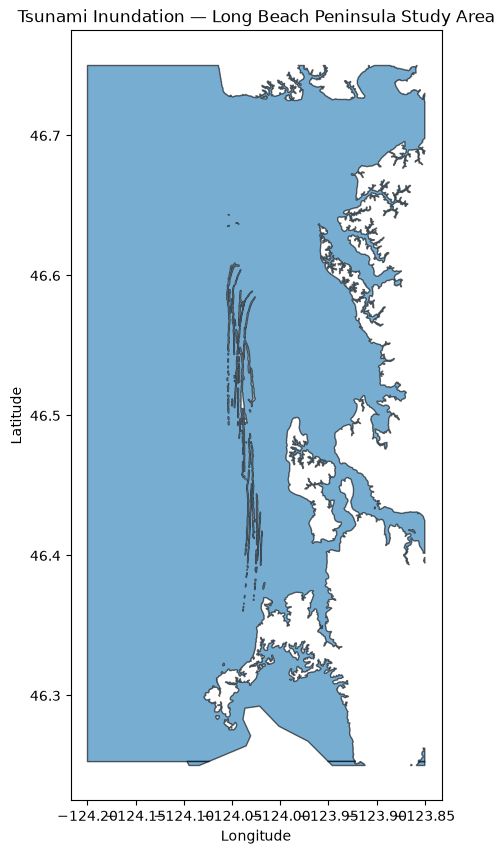

In [25]:
ax = long_beach_hazard.plot(
    figsize=(7, 10),
    edgecolor="black",
    alpha=0.6
)

ax.set_title("Tsunami Inundation — Long Beach Peninsula Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")